In [13]:
from DataProcessing import Readout
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy.ndimage import gaussian_filter
rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
	'font.size': 14,
	'axes.titlesize': 14,
	'axes.labelsize': 14,
	'xtick.labelsize': 14,
	'ytick.labelsize': 14,
	'legend.fontsize': 14,
	'figure.titlesize': 14,
	'legend.frameon': False,
})

In [138]:
root_dir = "Z:/migratedData/Rydberg_QIS/data"
_,_,atoms,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/04/08", plot_id=2)
atoms = atoms.T.astype(np.float64)
_,_,ref,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/04/08", plot_id=3)
ref = ref.T.astype(np.float64)
_,_,dark,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/04/08", plot_id=4)
dark = dark.T.astype(np.float64)

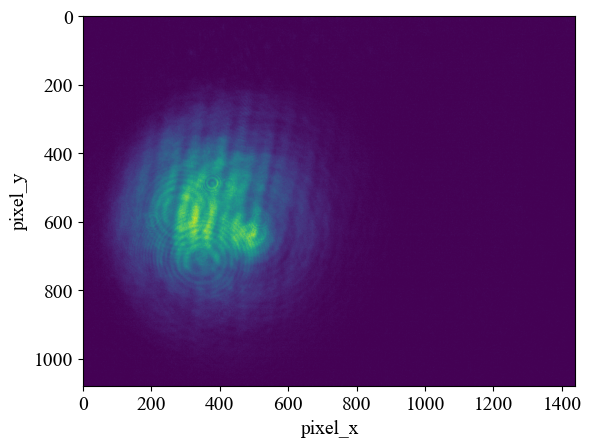

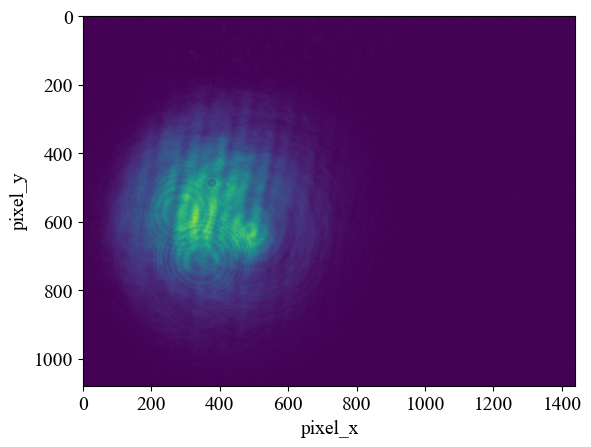

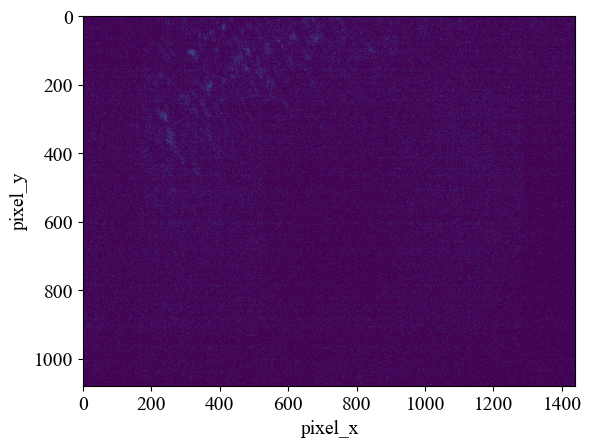

In [139]:
# plt.pcolormesh(x,y,z.T)
plt.imshow(atoms)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
plt.show()
# cbar = plt.colorbar()
# cbar.set_label(notes["zlabel"])

plt.imshow(ref)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
plt.show()

plt.imshow(dark)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
plt.show()

In [140]:
from scipy.ndimage import label

In [141]:
up = atoms-dark
print(up)
down = ref - dark
epsilon = 1e-6
threshold_OD = 0.05

mask = (down<=0) | (up <=0)

up[mask] = epsilon
down[mask] =epsilon
print(up)
ratio = up/down

print(ratio[:50,:50])

od = -np.log(ratio)

od_mask = od > threshold_OD

mot,label_num = label(od_mask)
print(label_num)
print(np.max(mot))

sizes= []
for i in range(1,label_num+1):
    size = np.sum((mot == i))
    
    sizes.append(size)

largest_label = np.argmax(sizes) + 1


# mot_mask = ( == largest_label)
# plt.imshow(od)
# plt.colorbar()
# plt.show()


# plt.imshow(mot_mask)
# plt.colorbar()
# plt.show()

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0. -1. ... -1.  0.  0.]
 ...
 [ 0. -1. -1. ...  0.  1.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[1.e-06 1.e-06 1.e-06 ... 1.e-06 1.e-06 1.e-06]
 [1.e-06 1.e-06 1.e-06 ... 1.e-06 1.e-06 1.e-06]
 [1.e-06 1.e-06 1.e-06 ... 1.e-06 1.e-06 1.e-06]
 ...
 [1.e-06 1.e-06 1.e-06 ... 1.e-06 1.e-06 1.e-06]
 [1.e-06 1.e-06 1.e-06 ... 1.e-06 1.e-06 1.e-06]
 [1.e-06 1.e-06 1.e-06 ... 1.e-06 1.e-06 1.e-06]]
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
48763
48763


In [228]:
od[od<0]=0

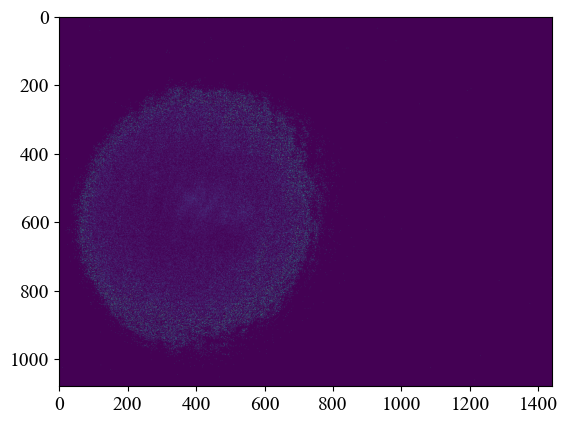

In [235]:
mot_mask = ( mot== largest_label)
plt.imshow(od)
# plt.figure(figsize=(32, 24))
# plt.colorbar()
plt.show()

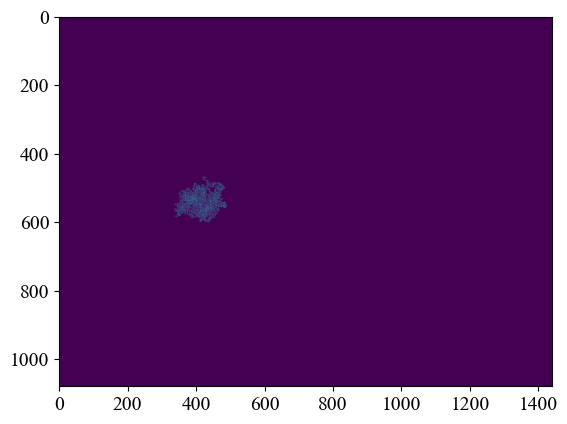

In [168]:


actual_MOT = od * mot_mask
plt.imshow(actual_MOT)
# plt.colorbar()
plt.show()

In [170]:
Isat = 31.3  # W/m^2


sigma0 = 4.849e-13  #m^2

pixel_size = 3.45e-06                   # camera pixel size [m]
mag_factor = 1.0                        # magnfication factor from 4f imaging system
A_pixel = (pixel_size/mag_factor)**2    # pixel area [m^2]



2.812e+04


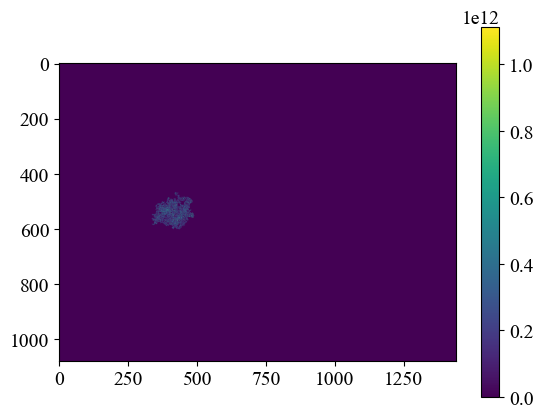

In [186]:
density = actual_MOT/(sigma0)
plt.imshow(density)
plt.colorbar()

total_num = np.sum(density * A_pixel)
print(f"{total_num:.3e}")

In [42]:
up.dtype

dtype('int64')